# Visión por Computadora I - CEIA

## Trabajo Práctico 2

Quiroga, Martin Gabriel
a2412

-----

### Objetivo
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: "focus_video.mov".

#### 1. Se debe implementar un algoritmo que dad una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
1. Medición sobre todo el frame
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Opcional:
Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc... (al menos 3)

Para cada experimento se debe presentar:
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detectó el punto de máximo enfoque.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = "focus_video.mov"
captura = cv.VideoCapture(video_path)

# Visualizar el video
fps = int(captura.get(cv.CAP_PROP_FPS))
print(f"FPS del video: {fps}")
delay = int(600/fps)

frames = []
bgr_frames = []
if not captura.isOpened():
    print("Error al abrir el video")
else:
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        cv.imshow("Video", frame)
        # Capturar los frames para después no tener que releer el video
        frames.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
        bgr_frames.append(frame)

        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

captura.release()
cv.destroyAllWindows()
print(f"{len(frames)} frames")


FPS del video: 29
171 frames


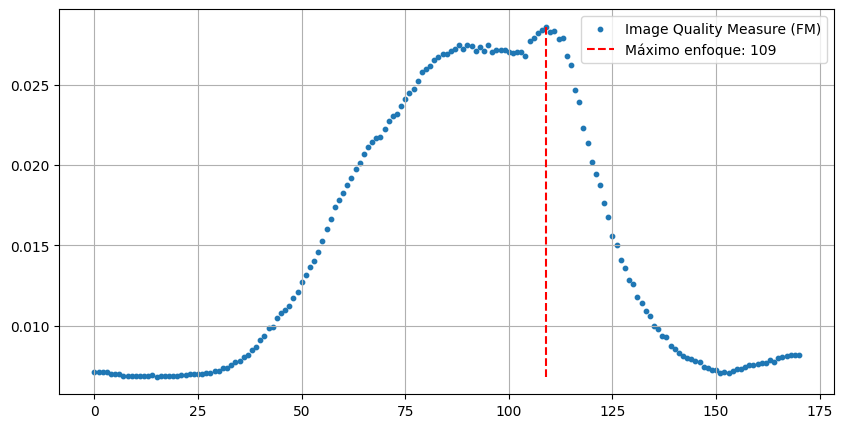

In [3]:
# Medición de sharpness(nitidez) sobre todo el frame
# Abrir el video nuevamente
captura = cv.VideoCapture(video_path)

# Obtener propiedades del video
frame_width = int(captura.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(captura.get(cv.CAP_PROP_FRAME_HEIGHT))

FM = []
for frame in frames:
    F = np.fft.fft2(frame)
    Fc = np.fft.fftshift(F) # Pasos 1 y 2
    AF = np.abs(Fc) # Paso 3
    M = np.max(AF) # Paso 4
    threshold = M * 0.001
    # F tiene valores complejos, pero es lo que indica el paper para usar
    # Analizar si lo correcto sería usar F o AF.
    Th = np.sum(np.where(AF > threshold, 1, 0)) # Paso 5

    FM.append(Th / (frame_width * frame_height))

max_focus_frame = np.argmax(FM)

plt.figure(figsize=(10, 5))
plt.scatter(
    range(len(FM)),
    FM,
    s=10,
    label="Image Quality Measure (FM)",

)
plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Máximo enfoque: {max_focus_frame}')
# plt.plot(FM, label="Image Quality Measure (FM)")
plt.legend()
plt.grid()
plt.show()


304 171 32 18


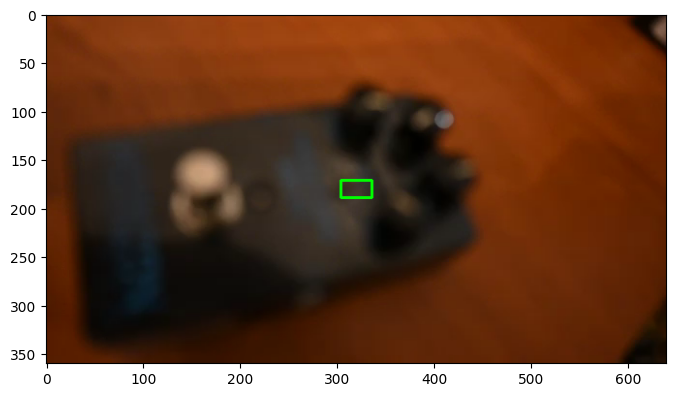

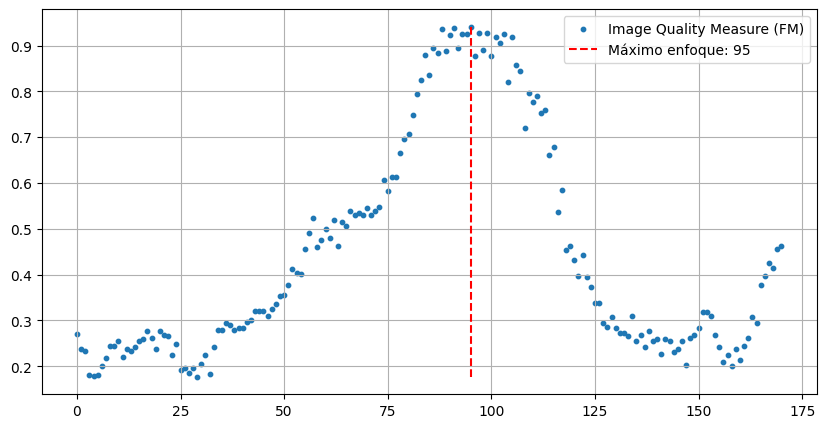

In [4]:
# Aplicarlo a una ROI en el centro
pcg = 0.05 # % del frame

ROI_width = int(frame_width * pcg)
ROI_height = int(frame_height * pcg)

ROI_center = (frame_width//2, frame_height//2)

x = ROI_center[0] - ROI_width//2
y = ROI_center[1] - ROI_height//2
w = ROI_width
h = ROI_height

print(x, y, w, h)
frame_con_roi = bgr_frames[0].copy()
cv.rectangle(frame_con_roi, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 5))
plt.imshow(cv.cvtColor(frame_con_roi, cv.COLOR_BGR2RGB))
plt.show()

FM = []
for frame in frames:
    roi = frame[y:y+h, x:x+w]
    F = np.fft.fft2(roi)
    Fc = np.fft.fftshift(F) # Pasos 1 y 2
    AF = np.abs(Fc) # Paso 3
    M = np.max(AF) # Paso 4
    threshold = M * 0.001
    Th = np.sum(np.where(AF > threshold, 1, 0)) # Paso 5

    FM.append(Th / (w * h))

max_focus_frame = np.argmax(FM)

# cv.imshow("ROI", roi)
plt.figure(figsize=(10, 5))
plt.scatter(
    range(len(FM)),
    FM,
    s=10,
    label="Image Quality Measure (FM)"
)
plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Máximo enfoque: {max_focus_frame}')
plt.legend()
plt.grid()
plt.show()


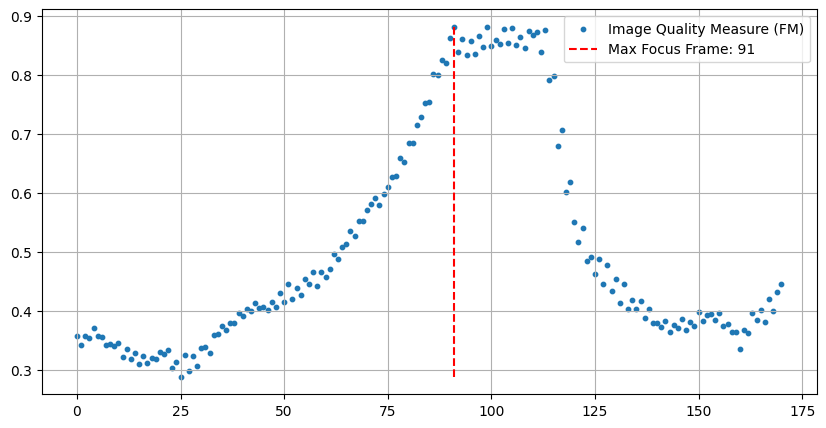

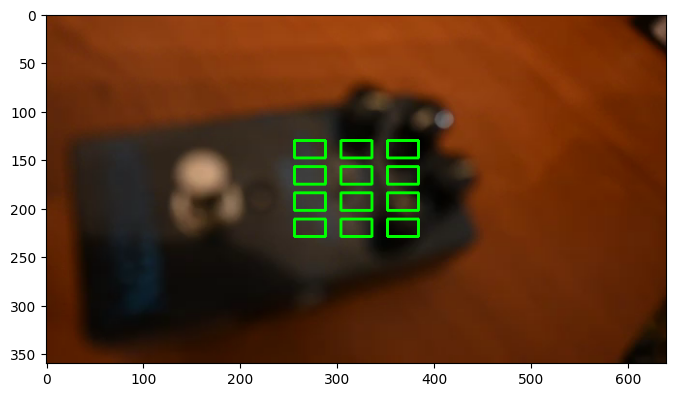

In [5]:
# Aplicarlo a un conjunto de ROI. Tiene que ser generalizable en el sentido
# de poder cambiar la cantidad de regiones de forma sencilla

ROI_rows = 3
ROI_columns = 4

pcg = 0.05 # % del frame

ROI_width = int(frame_width * pcg)
ROI_height = int(frame_height * pcg)

distance = 0.5  # Separación entre ROIs indicada como proporción del tamaño
                # de la ROI.

def get_ROI_coords(frame_width, frame_height, rows, columns, roi_width, roi_height, distance):
    # Calcular distancia entre los vértices de distintas ROIs
    dx = int(roi_width * (1 + distance))
    dy = int(roi_height * (1 + distance))

    # Calcular coordenadas de la primera ROI (esquina superior izquierda)
    start_x = (frame_width - (columns - 1) * dx - roi_width) // 2
    start_y = (frame_height - (rows - 1) * dy - roi_height) // 2

    coords = []
    for row in range(rows):
        for col in range(columns):
            x = start_x + col * dx
            y = start_y + row * dy
            coords.append((x, y, roi_width, roi_height))
    return coords

def evaluate_roi(frames, f_width, f_height, N, M, percentage=0.05, distance=0.5):
    roi_width = int(f_width * pcg)
    roi_height = int(f_height * pcg)
    rois=get_ROI_coords(
        frame_width=f_width,
        frame_height=f_height,
        rows=N,
        columns=M,
        roi_width=roi_width,
        roi_height=roi_height,
        distance=distance
    )
    FM = []
    for frame in frames:
        Th = 0
        rois_area = 0
        for roi in rois:
            x, y, w, h = roi[0], roi[1], roi[2], roi[3]
            roi = frame[y:y+h, x:x+w]
            F = np.fft.fft2(roi)
            Fc = np.fft.fftshift(F) # Pasos 1 y 2
            AF = np.abs(Fc) # Paso 3
            MAF = np.max(AF) # Paso 4, se cambia el nombre de la variable por conflicto
            threshold = MAF * 0.001
            Th += np.sum(np.where(AF > threshold, 1, 0)) # Paso 5
            rois_area += w * h

        FM.append(Th / rois_area)

    return FM, rois

def plot_FM_and_ROIs(FM, frame, ROIs):
    max_focus_frame = np.argmax(FM)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(
        range(len(FM)),
        FM,
        s=10,
        label="Image Quality Measure (FM)"
    )
    plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Max Focus Frame: {max_focus_frame}')
    plt.legend()
    plt.grid()
    plt.show()
    
    frame_con_rois = frame.copy()
    for roi in ROIs:
        cv.rectangle(frame_con_rois, (roi[0], roi[1]), (roi[0]+roi[2], roi[1]+roi[3]), (0, 255, 0), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv.cvtColor(frame_con_rois, cv.COLOR_BGR2RGB))
    plt.show()

FM1, rois1 = evaluate_roi(frames, frame_width, frame_height, 4, 3, distance=0.5)
plot_FM_and_ROIs(FM1, bgr_frames[0].copy(), rois1)

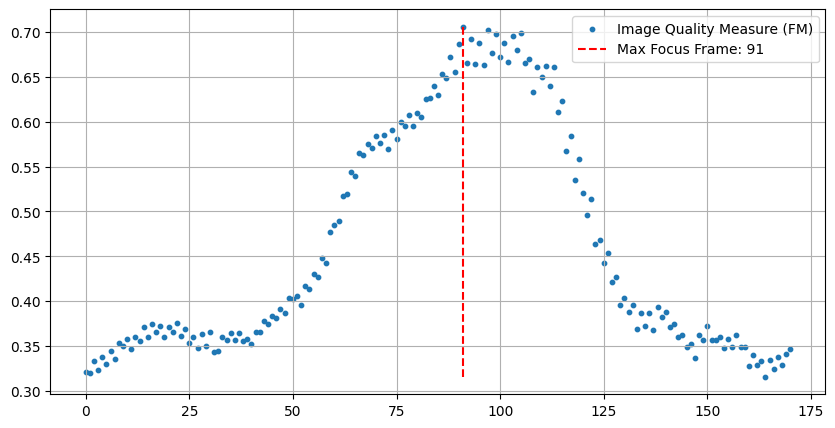

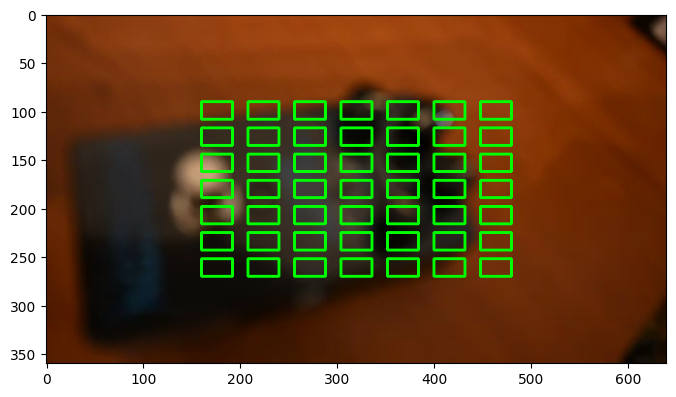

In [6]:
FM2, rois2 = evaluate_roi(frames, frame_width, frame_height, 7, 7, distance=0.5)
plot_FM_and_ROIs(FM2, bgr_frames[0].copy(), rois2)

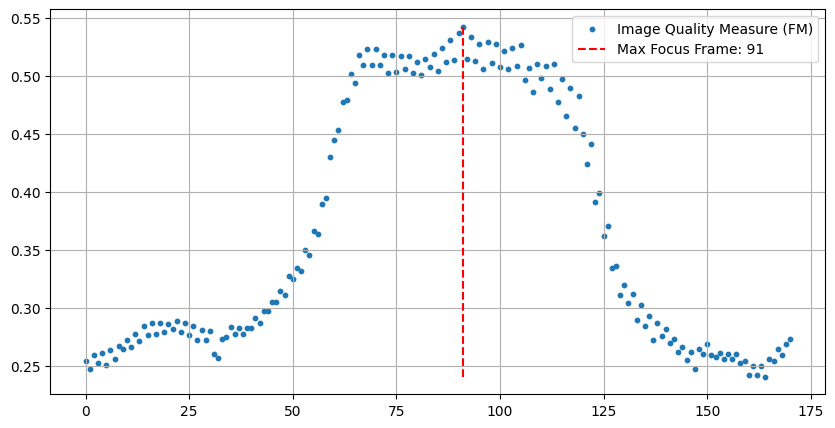

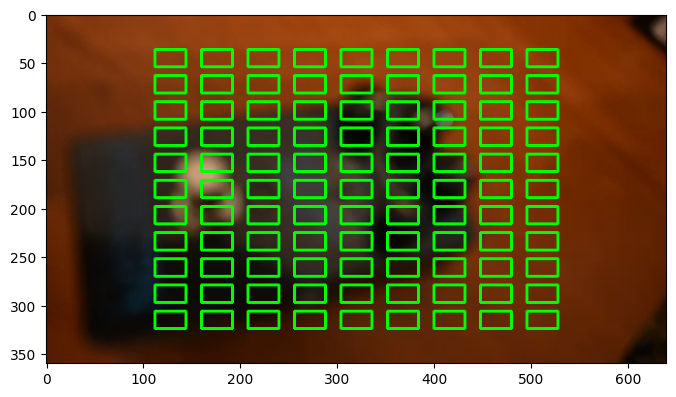

In [7]:
FM3, rois3 = evaluate_roi(frames, frame_width, frame_height, 11, 9, distance=0.5)
plot_FM_and_ROIs(FM3, bgr_frames[0].copy(), rois3)

#### 2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shape-from-focus.